# Prototype Distortion Task

Human category learning experiment.

The experiment consists of:
1. Training on examples of "leptons"
2. Training on examples of "non-leptons"
3. Classification of previously seen and unseen test stimuli
4. Plotting the proportion of "lepton" responses as a function of distance from the prototype

Run the notebook from top to bottom. Training, testing, and the final result plot use normal interactive Matplotlib windows.


## Setup and functions


In [1]:
# Use normal interactive Matplotlib windows rather than inline notebook figures.
%matplotlib qt

import numpy as np
import matplotlib.pyplot as plt


def generate_stimuli(prototype, distance, n_stimuli):
    """Generate stimuli at a fixed Euclidean distance from the prototype."""

    n_dimensions = len(prototype)

    # Generate uniformly random directions on the hypersphere.
    directions = np.random.randn(n_stimuli, n_dimensions)

    # Normalise every direction to unit length.
    lengths = np.sqrt(np.sum(directions**2, axis=1))
    directions = directions / lengths[:, np.newaxis]

    # Scale to the requested distance.
    directions = distance * directions

    # Shift so that the vectors surround the prototype.
    stimuli = directions + prototype

    return stimuli


def plot_stimulus(ax, stimulus, dot_colors, x_limits, y_limits):
    """Plot one configuration of coloured dots."""

    n_dots = len(dot_colors)

    for d in range(n_dots):
        x = stimulus[2*d]
        y = stimulus[2*d + 1]

        ax.plot(
            x, y, 'o',
            markerfacecolor=dot_colors[d],
            markeredgecolor=dot_colors[d],
            markersize=15
        )

    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.set_xticks([])
    ax.set_yticks([])


def show_training_set(stimuli, dot_colors, x_limits, y_limits, plot_title):
    """Display all training examples in a 3 x 5 grid."""

    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    axes = axes.flatten()

    for i in range(len(stimuli)):
        plot_stimulus(
            axes[i],
            stimuli[i],
            dot_colors,
            x_limits,
            y_limits
        )

    fig.suptitle(plot_title, fontsize=16, color='red')
    plt.tight_layout()

    # Show the figure and wait until a key or mouse button is pressed.
    plt.show(block=False)
    plt.waitforbuttonpress()
    plt.close(fig)


def get_yes_no_response(fig):
    """Wait for Y or N. Mouse clicks and other keys are ignored."""

    response = None

    def on_key(event):
        nonlocal response

        if event.key is None:
            return

        if event.key.lower() == 'y':
            response = 1
        elif event.key.lower() == 'n':
            response = 0

    connection = fig.canvas.mpl_connect('key_press_event', on_key)

    while response is None:
        plt.pause(0.01)

    fig.canvas.mpl_disconnect(connection)

    return response


## Experiment parameters


In [2]:
n_dots = 3
n_training = 15

lepton_distance = 1.5
non_lepton_distance = 2.5

test_distances = np.array([1.0, 1.5, 2.0, 2.5])
n_test_per_distance = 15

n_dimensions = 2 * n_dots

dot_colors = ['red', 'green', 'blue']


## Generate prototype and stimuli


In [3]:
# The prototype is a random point in the six-dimensional feature space.

prototype = 2 * (np.random.rand(n_dimensions) - 0.5)


# Generate training stimuli.

training_leptons = generate_stimuli(
    prototype,
    lepton_distance,
    n_training
)

training_non_leptons = generate_stimuli(
    prototype,
    non_lepton_distance,
    n_training
)


# Generate unseen test stimuli.

test_stimuli = np.zeros(
    (len(test_distances), n_test_per_distance, n_dimensions)
)

for i in range(len(test_distances)):
    test_stimuli[i, :, :] = generate_stimuli(
        prototype,
        test_distances[i],
        n_test_per_distance
    )


## Determine common plot limits


In [4]:
# All stimuli are shown using the same axis limits so that their
# absolute positions are directly comparable.

all_stimuli = np.vstack([
    training_leptons,
    training_non_leptons,
    test_stimuli.reshape(-1, n_dimensions)
])

x_coordinates = all_stimuli[:, 0::2]
y_coordinates = all_stimuli[:, 1::2]

x_limits = [
    np.min(x_coordinates),
    np.max(x_coordinates)
]

y_limits = [
    np.min(y_coordinates),
    np.max(y_coordinates)
]

margin = 0.2

x_limits = [
    x_limits[0] - margin,
    x_limits[1] + margin
]

y_limits = [
    y_limits[0] - margin,
    y_limits[1] + margin
]


## Training phase: Leptons

A Matplotlib window will open. Press any key or click the window when you are ready to continue.


In [9]:
show_training_set(
    training_leptons,
    dot_colors,
    x_limits,
    y_limits,
    'Look at all these Leptons!'
)


## Training phase: non-Leptons

Again, press any key or click the window when you are ready to continue.


In [10]:
show_training_set(
    training_non_leptons,
    dot_colors,
    x_limits,
    y_limits,
    'These are not Leptons!'
)


## Construct and randomise test trials


In [11]:
# Previously seen stimuli.

seen_stimuli = np.vstack([
    training_leptons,
    training_non_leptons
])

seen_distances = np.concatenate([
    np.full(n_training, lepton_distance),
    np.full(n_training, non_lepton_distance)
])

seen_before = np.ones(2 * n_training, dtype=bool)


# Unseen stimuli.

unseen_stimuli = test_stimuli.reshape(
    -1,
    n_dimensions
)

unseen_distances = np.repeat(
    test_distances,
    n_test_per_distance
)

unseen_before = np.zeros(
    len(unseen_distances),
    dtype=bool
)


# Combine all trials.

trial_stimuli = np.vstack([
    seen_stimuli,
    unseen_stimuli
])

trial_distances = np.concatenate([
    seen_distances,
    unseen_distances
])

trial_seen = np.concatenate([
    seen_before,
    unseen_before
])

n_trials = len(trial_distances)


# Randomise trial order.

trial_order = np.random.permutation(n_trials)

trial_stimuli = trial_stimuli[trial_order]
trial_distances = trial_distances[trial_order]
trial_seen = trial_seen[trial_order]


## Test phase

A Matplotlib window will open. Keep that window active.

Press **Y** if the stimulus is a Lepton or **N** if it is not. Mouse clicks and other keys are ignored.


In [12]:
responses = np.zeros(n_trials, dtype=int)

fig = plt.figure(figsize=(15, 9))
plt.show(block=False)

for trial in range(n_trials):

    fig.clear()

    # Use the same 3 x 5 subplot geometry as during training.
    ax = fig.add_subplot(3, 5, 8)

    plot_stimulus(
        ax,
        trial_stimuli[trial],
        dot_colors,
        x_limits,
        y_limits
    )

    ax.set_title(
        f'Is this a Lepton? (Y/N)   Trial {trial + 1}/{n_trials}',
        fontsize=12
    )

    fig.canvas.draw()
    fig.canvas.flush_events()

    responses[trial] = get_yes_no_response(fig)

plt.close(fig)


## Analyse results


In [13]:
# Analyse unseen test stimuli.

p_lepton_unseen = np.zeros(len(test_distances))
se_unseen = np.zeros(len(test_distances))

for i in range(len(test_distances)):

    idx = (
        (~trial_seen) &
        (trial_distances == test_distances[i])
    )

    p_lepton_unseen[i] = np.mean(responses[idx])

    n = np.sum(idx)

    se_unseen[i] = np.sqrt(
        p_lepton_unseen[i] *
        (1 - p_lepton_unseen[i]) / n
    )


# Analyse previously seen stimuli.

seen_distances_to_plot = np.array([
    lepton_distance,
    non_lepton_distance
])

p_lepton_seen = np.zeros(len(seen_distances_to_plot))
se_seen = np.zeros(len(seen_distances_to_plot))

for i in range(len(seen_distances_to_plot)):

    idx = (
        trial_seen &
        (trial_distances == seen_distances_to_plot[i])
    )

    p_lepton_seen[i] = np.mean(responses[idx])

    n = np.sum(idx)

    se_seen[i] = np.sqrt(
        p_lepton_seen[i] *
        (1 - p_lepton_seen[i]) / n
    )


## Plot results


In [14]:
# Put seen and unseen data on the same x-axis.

p_seen_plot = np.array([
    np.nan,
    p_lepton_seen[0],
    np.nan,
    p_lepton_seen[1]
])

se_seen_plot = np.array([
    np.nan,
    se_seen[0],
    np.nan,
    se_seen[1]
])


fig, axes = plt.subplots(2, 1, figsize=(7, 7))


# Unseen stimuli.

axes[0].bar(
    test_distances,
    100 * p_lepton_unseen,
    width=0.4
)

axes[0].errorbar(
    test_distances,
    100 * p_lepton_unseen,
    yerr=100 * se_unseen,
    fmt='ko',
    linestyle='none'
)

axes[0].set_xlim(0.5, 3)
axes[0].set_ylim(0, 100)
axes[0].set_xticks(test_distances)
axes[0].set_xlabel('Distance from prototype')
axes[0].set_ylabel('Lepton responses (%)')
axes[0].set_title('Previously unseen stimuli')


# Previously seen stimuli.

axes[1].bar(
    test_distances,
    100 * p_seen_plot,
    width=0.4
)

axes[1].errorbar(
    test_distances,
    100 * p_seen_plot,
    yerr=100 * se_seen_plot,
    fmt='ko',
    linestyle='none'
)

axes[1].set_xlim(0.5, 3)
axes[1].set_ylim(0, 100)
axes[1].set_xticks(test_distances)
axes[1].set_xlabel('Distance from prototype')
axes[1].set_ylabel('Lepton responses (%)')
axes[1].set_title('Previously seen training stimuli')

plt.tight_layout()

plt.savefig(
    'PrototypeDistortionResult.png',
    dpi=300
)

plt.show()


## Save trial-by-trial results


In [15]:
# Three columns:
# distance, seen during training, lepton response

results = np.column_stack([
    trial_distances,
    trial_seen.astype(int),
    responses
])

np.savetxt(
    'PrototypeDistortionResult.csv',
    results,
    delimiter=',',
    header='Distance,SeenDuringTraining,LeptonResponse',
    comments='',
    fmt=['%.1f', '%d', '%d']
)


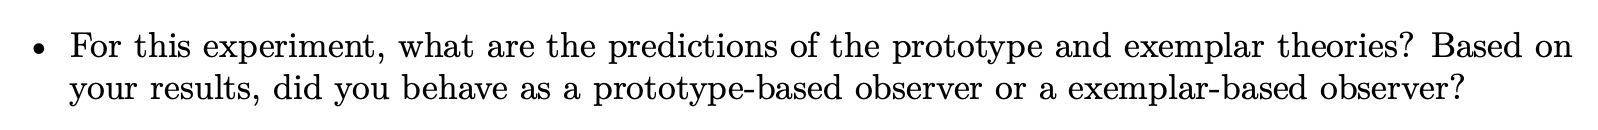

#### Prototype theory predicts that the observer forms an abstract average of the Leptons and classifies new stimuli by their distance to it, so Lepton responses should decrease with distance and be the same for seen and unseen stimuli at the same distance. Exemplar theory predicts that the observer stores the individual training examples, so previously seen stimuli should be classified more accurately than unseen stimuli at the same distance.

#### In my results, Lepton responses for unseen stimuli fell with distance (100%, 80%, 60%, 27%) and were highest at distance 1.0, which is closer to the prototype than any training example. I showed no advantage for seen stimuli: training Leptons were called Leptons less often than unseen stimuli at 1.5 (60% vs 80%), and training non-Leptons more often than unseen stimuli at 2.5 (47% vs 27%). I therefore behaved as a prototype-based observer, although with 15 trials per condition the differences between seen and unseen stimuli are uncertain.